# Chapter 11 Training Deep Neural Networks
## Section 2 Reusing Pretrained Layers

In [33]:
import tensorflow as tf
import tensorflow.keras as keras

physical_devices = tf.config.list_physical_devices("GPU")
for device in physical_devices:
    tf.config.experimental.set_memory_growth(device, True)

__Get data__

In [34]:
from tensorflow.keras.datasets import fashion_mnist

(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()

In [35]:
# Add class names
import numpy as np

class_names = np.array(
    [
        "T-shirt/top",
        "Trouser",
        "Pullover",
        "Dress",
        "Coat",
        "Sandal",
        "Shirt",
        "Sneaker",
        "Bag",
        "Ankle boot",
    ]
)

__Explore data__

Data shape

In [36]:
print("Shapes:")
print(f"- X_train_full: {X_train_full.shape}")
print(f"- y_train_full: {y_train_full.shape}")
print(f"- X_test: {X_test.shape}")

Shapes:
- X_train_full: (60000, 28, 28)
- y_train_full: (60000,)
- X_test: (10000, 28, 28)


Data description

In [37]:
import pandas as pd

pd.DataFrame(X_train_full.ravel()).describe()

,0
count,4.704000e+07
mean,7.294035e+01
std,9.002118e+01
min,0.000000e+00
25%,0.000000e+00
50%,0.000000e+00
75%,1.630000e+02
max,2.550000e+02


In [38]:
pd.DataFrame(y_train_full.ravel()).describe()

,0
count,60000.000000
mean,4.500000
std,2.872305
min,0.000000
25%,2.000000
50%,4.500000
75%,7.000000
max,9.000000


Visualize data

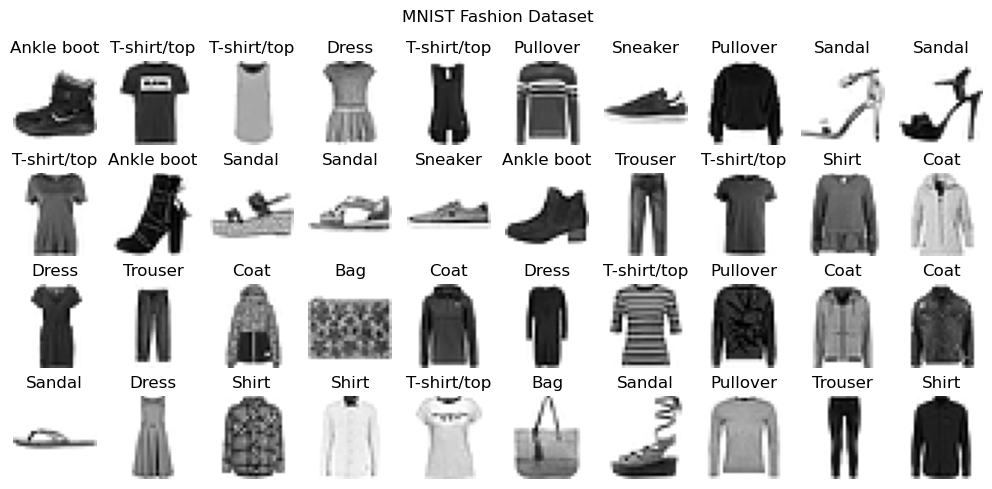

In [39]:
import matplotlib.pyplot as plt
from typing import Sequence


def visualize_images(
    images: Sequence[Sequence[float]],
    labels: Sequence[str],
    cmap: str = "gray",
    n_cols: int = 5,
) -> None:
    """Visualize images

    Parameters
    ----------
    images : Sequence[Sequence[float]]
        Input images in shape (n_images, n_pixels_in_row, n_pixels_col). Pixel values should be normalized to 0~1 float
        or 0~255 int.
    labels : Sequence[str]
        Labels of each images.
    cmap : str
        Color map.
    n_cols : int
        Number of images per row. Default 5.

    Returns
    -------
    None

    """
    n_images = len(images)
    n_rows = round(np.ceil(n_images / n_cols))

    fig, axes = plt.subplots(
        nrows=n_rows, ncols=n_cols, squeeze=False, figsize=(10, 1 * n_rows + 1)
    )
    for ax, image, label in zip(axes.ravel(), images, labels):
        ax.imshow(image, cmap=cmap)
        ax.set_title(label)
        ax.axis("off")

    fig.suptitle("MNIST Fashion Dataset")
    plt.tight_layout()


visualize_images(
    X_train_full[:40], class_names[y_train_full[:40]], cmap="gray_r", n_cols=10
)
plt.show()

__Prepare data__

Normalize data

In [40]:
from sklearn.model_selection import train_test_split

X_train_full_norm = X_train_full / 255.0
X_test_norm = X_test / 255.0

Data for the base model and the transfer-learned model

In [41]:
ids_train_base = np.logical_and(y_train_full != 5, y_train_full != 6)
ids_train_transfer = np.logical_not(ids_train_base)
ids_test_base = np.logical_and(y_test != 5, y_test != 6)
ids_test_transfer = np.logical_not(ids_test_base)

X_train_base_full = X_train_full_norm[ids_train_base]
X_train_transfer_full = X_train_full_norm[ids_train_transfer]
X_test_base = X_test_norm[ids_test_base]
X_test_transfer = X_test_norm[ids_test_transfer]

y_train_base_full = y_train_full[ids_train_base]
y_train_transfer_full = y_train_full[ids_train_transfer]
y_test_base = y_test[ids_test_base]
y_test_transfer = y_test[ids_test_transfer]


def sort_label_base(y_base: np.ndarray):
    return np.vectorize(lambda label: label if label < 5 else label - 2)(y_base)


y_train_base_full = sort_label_base(y_train_base_full)
y_test_base_full = sort_label_base(y_test_base)
y_train_transfer_full = y_train_transfer_full - 5
y_test_transfer = y_test_transfer - 5

In [42]:
X_train_base_full.shape

(48000, 28, 28)

In [43]:
X_train_transfer_full.shape

(12000, 28, 28)

In [44]:
X_test_base.shape

(8000, 28, 28)

In [45]:
X_test_transfer.shape

(2000, 28, 28)

In [46]:
pd.DataFrame(y_train_base_full).describe()

,0
count,48000.000000
mean,3.500000
std,2.291312
min,0.000000
25%,1.750000
50%,3.500000
75%,5.250000
max,7.000000


In [47]:
pd.DataFrame(y_train_transfer_full).describe()

,0
count,12000.000000
mean,0.500000
std,0.500021
min,0.000000
25%,0.000000
50%,0.500000
75%,1.000000
max,1.000000


Train-test-split data

In [48]:
X_train_base, X_valid_base, y_train_base, y_valid_base = train_test_split(
    X_train_base_full, y_train_base_full, random_state=42
)
X_train_transfer, X_valid_transfer, y_train_transfer, y_valid_transfer = (
    train_test_split(X_train_transfer_full, y_train_transfer_full, random_state=42)
)

__Train a base model__

Build model

In [49]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten

model_base = Sequential(
    [
        Flatten(input_shape=(28, 28)),
        Dense(300, activation="selu", kernel_initializer="lecun_normal"),
        Dense(100, activation="selu", kernel_initializer="lecun_normal"),
        Dense(8, activation="softmax"),
    ]
)
model_base.summary()

Model: "sequential_2"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
flatten_1 (Flatten)          (None, 784)               0         
_________________________________________________________________
dense_4 (Dense)              (None, 300)               235500    
_________________________________________________________________
dense_5 (Dense)              (None, 100)               30100     
_________________________________________________________________
dense_6 (Dense)              (None, 8)                 808       
Total params: 266,408
Trainable params: 266,408
Non-trainable params: 0
_________________________________________________________________


Compile model

In [50]:
model_base.compile(
    loss="sparse_categorical_crossentropy", optimizer="adam", metrics=["acc"]
)

Train model

In [51]:
from pathlib import Path

dir_log_root = Path() / "my_logs"


def get_log_dir() -> str:
    import time

    run_id = time.strftime("run_%Y_%m_%d-%H_%M_%S")
    return str(dir_log_root / run_id)

In [52]:
from tensorflow.keras.callbacks import EarlyStopping, TensorBoard

history = model_base.fit(
    X_train_base,
    y_train_base,
    validation_data=(X_valid_base, y_valid_base),
    epochs=100,
    callbacks=[
        EarlyStopping(patience=10, restore_best_weights=True),
        TensorBoard(get_log_dir()),
    ],
)

Epoch 1/100
1125/1125 [==============================] - 3s 2ms/step - loss: 0.4281 - acc: 0.8512 - val_loss: 0.2755 - val_acc: 0.9053
Epoch 2/100
1125/1125 [==============================] - 2s 2ms/step - loss: 0.2659 - acc: 0.9050 - val_loss: 0.2747 - val_acc: 0.9044
Epoch 3/100
1125/1125 [==============================] - 2s 2ms/step - loss: 0.2333 - acc: 0.9180 - val_loss: 0.2448 - val_acc: 0.9170
Epoch 4/100
1125/1125 [==============================] - 2s 2ms/step - loss: 0.2171 - acc: 0.9210 - val_loss: 0.2275 - val_acc: 0.9228
Epoch 5/100
1125/1125 [==============================] - 2s 2ms/step - loss: 0.2069 - acc: 0.9238 - val_loss: 0.2421 - val_acc: 0.9168
Epoch 6/100
1125/1125 [==============================] - 2s 2ms/step - loss: 0.1860 - acc: 0.9316 - val_loss: 0.2546 - val_acc: 0.9112
Epoch 7/100
1125/1125 [==============================] - 2s 2ms/step - loss: 0.1762 - acc: 0.9318 - val_loss: 0.2039 - val_acc: 0.9308
Epoch 8/100
1125/1125 [==============================] 

In [53]:
model_base.evaluate(X_test_base, y_test_base)

250/250 [==============================] - 1s 2ms/step - loss: nan - acc: 0.5617


[nan, 0.5617499947547913]

Save model

In [54]:
path_model_base = "base_model.h5"
model_base.save(path_model_base)

__Transfer learning__

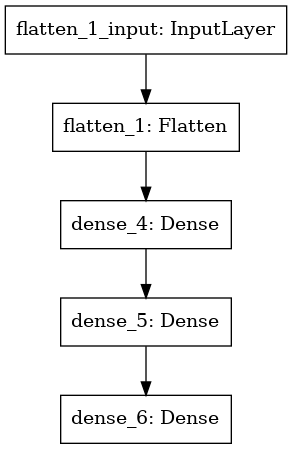

In [55]:
model_base = keras.models.load_model(path_model_base)
keras.utils.plot_model(model_base)

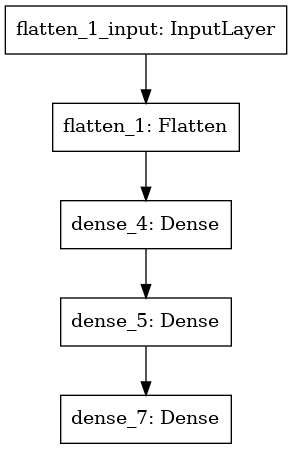

In [56]:
model_base_clone = keras.models.clone_model(model_base)
model_base_clone.set_weights(model_base.get_weights())
model_transfer = keras.models.Sequential(model_base_clone.layers[:-1])
model_transfer.add(Dense(1, activation="sigmoid"))
keras.utils.plot_model(model_transfer)

In [57]:
for layer in model_transfer.layers[:-1]:
    layer.trainable = False

In [58]:
model_transfer.compile(loss="binary_crossentropy", metrics=["accuracy"])
model_transfer.summary()

Model: "sequential_3"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
flatten_1 (Flatten)          (None, 784)               0         
_________________________________________________________________
dense_4 (Dense)              (None, 300)               235500    
_________________________________________________________________
dense_5 (Dense)              (None, 100)               30100     
_________________________________________________________________
dense_7 (Dense)              (None, 1)                 101       
Total params: 265,701
Trainable params: 101
Non-trainable params: 265,600
_________________________________________________________________


In [59]:
history = model_transfer.fit(
    X_train_transfer,
    y_train_transfer,
    epochs=4,
    callbacks=[TensorBoard(get_log_dir())],
    validation_data=(X_valid_transfer, y_valid_transfer),
)

Epoch 1/4
282/282 [==============================] - 1s 2ms/step - loss: 0.4264 - accuracy: 0.8222 - val_loss: 0.0092 - val_accuracy: 0.9983
Epoch 2/4
282/282 [==============================] - 1s 2ms/step - loss: 0.0095 - accuracy: 0.9974 - val_loss: 0.0047 - val_accuracy: 0.9990
Epoch 3/4
282/282 [==============================] - 1s 2ms/step - loss: 0.0055 - accuracy: 0.9979 - val_loss: 0.0035 - val_accuracy: 0.9990
Epoch 4/4
282/282 [==============================] - 1s 2ms/step - loss: 0.0053 - accuracy: 0.9983 - val_loss: 0.0025 - val_accuracy: 0.9990


In [60]:
model_transfer.evaluate(X_test_transfer, y_test_transfer)

63/63 [==============================] - 0s 1ms/step - loss: 0.0028 - accuracy: 0.9990


[0.002793338382616639, 0.9990000128746033]

In [61]:
for layer in model_transfer.layers:
    layer.trainable = True

In [62]:
model_transfer.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

In [63]:
hisroty = model_transfer.fit(
    X_train_transfer,
    y_train_transfer,
    validation_data=(X_valid_transfer, y_valid_transfer),
    epochs=16,
    callbacks=[TensorBoard(get_log_dir())],
)

Epoch 1/16
282/282 [==============================] - 1s 2ms/step - loss: 0.0031 - accuracy: 0.9992 - val_loss: 9.1797e-04 - val_accuracy: 1.0000
Epoch 2/16
282/282 [==============================] - 1s 2ms/step - loss: 0.0011 - accuracy: 0.9998 - val_loss: 7.7176e-04 - val_accuracy: 0.9997
Epoch 3/16
282/282 [==============================] - 1s 2ms/step - loss: 5.6675e-04 - accuracy: 1.0000 - val_loss: 7.5959e-04 - val_accuracy: 0.9997
Epoch 4/16
282/282 [==============================] - 1s 2ms/step - loss: 3.7311e-04 - accuracy: 0.9999 - val_loss: 5.3483e-04 - val_accuracy: 1.0000
Epoch 5/16
282/282 [==============================] - 1s 2ms/step - loss: 2.8447e-04 - accuracy: 1.0000 - val_loss: 3.1292e-04 - val_accuracy: 1.0000
Epoch 6/16
282/282 [==============================] - 1s 2ms/step - loss: 1.5140e-04 - accuracy: 1.0000 - val_loss: 3.2902e-04 - val_accuracy: 1.0000
Epoch 7/16
282/282 [==============================] - 1s 2ms/step - loss: 1.0279e-04 - accuracy: 1.0000 - va

In [64]:
model_transfer.evaluate(X_test_transfer, y_test_transfer)

63/63 [==============================] - 0s 1ms/step - loss: 2.3905e-04 - accuracy: 1.0000


[0.0002390522276982665, 1.0]